In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export_torch.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28178 entries, 0 to 28177
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  28178 non-null  str  
 1   Message  28178 non-null  str  
 2   Status   28178 non-null  str  
dtypes: str(3)
memory usage: 660.6 KB


In [3]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
02    18796
03     8046
09      784
04      506
01       39
11        7
Name: count, dtype: int64

In [4]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])

torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133],16))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(torch_codes_0204.iloc[i,2][150:154])
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

torch_codes_0204_ordered=torch_codes_0204.sort_values('date',ascending=True)

print(torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','engine_load']])

       i_on  i_off                  io  odometer          date  ext_ps  speed  \
22       25    600  0b1100000000000000         0  260210054959    0.53      0   
23       25    600  0b1100000000000000         0  260210055000    0.52      0   
24       25    600  0b1100000000000000         0  260210055405    0.49      0   
25       25    600  0b1000000000000000         0  260210055417    0.48      0   
26       25    600  0b1000000000000000         0  260520211828    4.92      0   
...     ...    ...                 ...       ...           ...     ...    ...   
28169    25    300                 0b0  87226615  260622154852   12.67      0   
28170    25    300                 0b0  87226615  260622155352   12.66      0   
28173    25    300                 0b0  87226615  260622155851   12.67      0   
28175    25    300                 0b0  87226615  260622160352   12.62      0   
28177    25    300                 0b0  87226615  260622160852   12.66      0   

       acc_fuel_c   rpm rem

In [5]:
torch_codes_0204_ordered.info()

<class 'pandas.DataFrame'>
Index: 19302 entries, 22 to 28177
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      19302 non-null  str    
 1   Message      19302 non-null  str    
 2   Status       19302 non-null  str    
 3   Codes        19302 non-null  str    
 4   i_on         19302 non-null  int64  
 5   i_off        19302 non-null  int64  
 6   io           19302 non-null  str    
 7   odometer     19302 non-null  int64  
 8   date         19302 non-null  str    
 9   ext_ps       19302 non-null  float64
 10  speed        19302 non-null  int64  
 11  gnss         19302 non-null  int64  
 12  acc_fuel_c   19302 non-null  float64
 13  rpm          19302 non-null  str    
 14  cool_temp    19302 non-null  int64  
 15  remain_fuel  19302 non-null  str    
 16  engine_load  19302 non-null  int64  
dtypes: float64(2), int64(7), str(8)
memory usage: 2.7 MB


In [6]:
df=torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]
df.info()

<class 'pandas.DataFrame'>
Index: 19302 entries, 22 to 28177
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         19302 non-null  int64  
 1   i_off        19302 non-null  int64  
 2   io           19302 non-null  str    
 3   odometer     19302 non-null  int64  
 4   date         19302 non-null  str    
 5   ext_ps       19302 non-null  float64
 6   speed        19302 non-null  int64  
 7   acc_fuel_c   19302 non-null  float64
 8   rpm          19302 non-null  str    
 9   remain_fuel  19302 non-null  str    
 10  gnss         19302 non-null  int64  
 11  cool_temp    19302 non-null  int64  
 12  Status       19302 non-null  str    
 13  engine_load  19302 non-null  int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 2.2 MB


Odometer

87226615 86336000


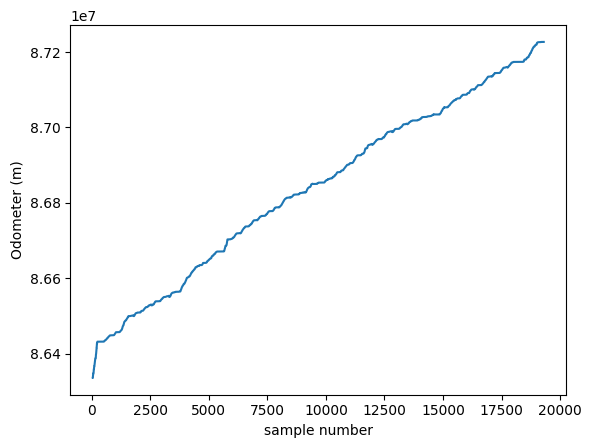

In [7]:
odometer=pd.DataFrame()
odometer_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if int(df.iloc[i,3]>80000000):
        status.append(df.iloc[i,12])
        odometer_data.append(int(df.iloc[i,3]))
        date.append(df.iloc[i,4])
        x_axis.append(i)

print(max(odometer_data),min(odometer_data))
odometer['sample_number']=x_axis
odometer['odometer']=odometer_data
odometer['date']=date
odometer['status']=status

plt.ylabel("Odometer (m)")
plt.xlabel('sample number')
#plt.xticks(range(0,5572,100),rotation=90)
plt.plot(x_axis,odometer_data)

odometer.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\odometer.csv')

The lower peak was caused by MinsDiff=504.
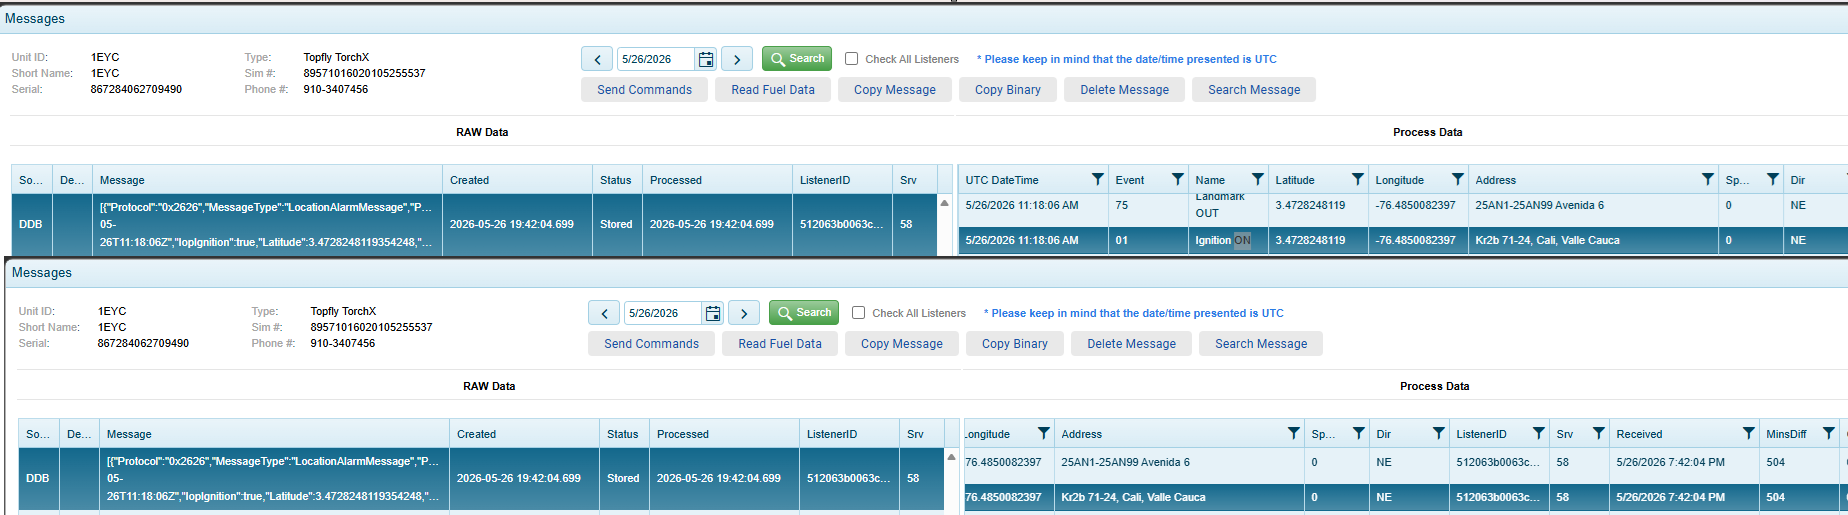

Speed

120 0


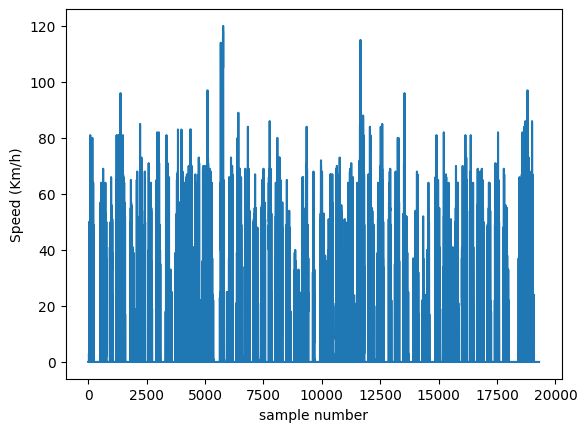

In [8]:
speed=pd.DataFrame()
speed_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):                        
        status.append(df.iloc[i,12])
        speed_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(speed_data),min(speed_data))
speed['sample_number']=x_axis
speed['speed']=speed_data
speed['status']=status

plt.ylabel("Speed (Km/h)")
plt.xlabel('sample number')
plt.plot(x_axis,speed_data)

speed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\speed.csv')

RPM

120 0


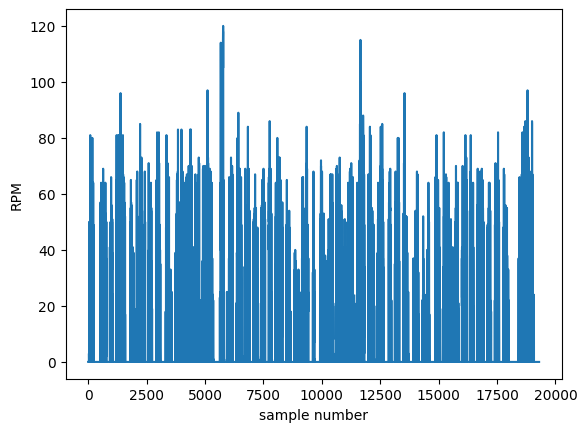

In [9]:
rpm=pd.DataFrame()
rpm_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
        status.append(df.iloc[i,12])
        rpm_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(rpm_data),min(rpm_data))
rpm['sample_number']=x_axis
rpm['rpm']=speed_data
rpm['status']=status

plt.ylabel("RPM")
plt.xlabel('sample number')
plt.plot(x_axis,rpm_data)
rpm.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rpm.csv')

Fuel

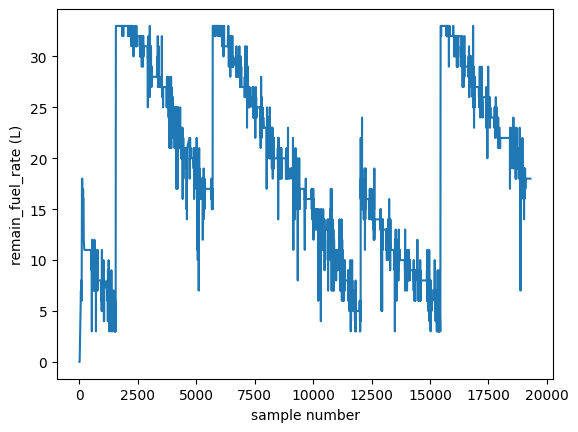

In [10]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

rfl['fuel_data']=fuel_data
rfl['date']=date
rfl['raw_data']=status
rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl.csv',sep=',')

Fuel smoothing

Charth with averaging_sample number= 100


Text(0.5, 0, 'sample number')

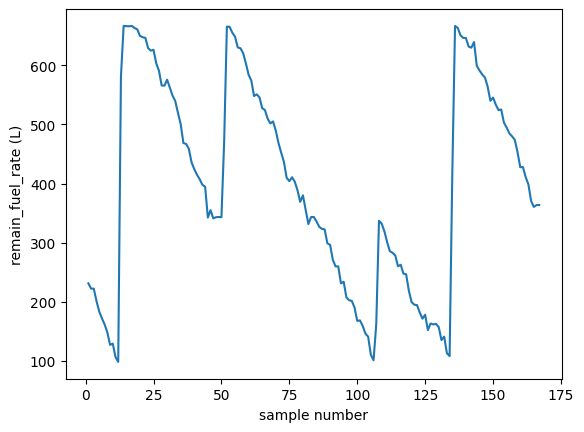

In [11]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
x_axis_5=[]
date=[]
status=[]
status_aux=[]
aux_5=0
cont_5=0
avg_5=[]
i_5=0
averaging_sample=int(input("Typr the averaging sample number: "))

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])
            aux_5=aux_5+(int(df.iloc[i,9],16) & 127)
            cont_5=cont_5+1
            if cont_5>averaging_sample:                   #Test
                i_5=i_5+1                
                cont_5=0
                avg_5.append(aux_5/5)
                aux_5=0
                x_axis_5.append(i_5)

print("Charth with averaging_sample number=",averaging_sample)

plt.plot(x_axis_5,avg_5)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

#rfl['fuel_data']=fuel_data
#rfl['date']=date
#rfl['raw_data']=status
#rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl.csv',sep=',')

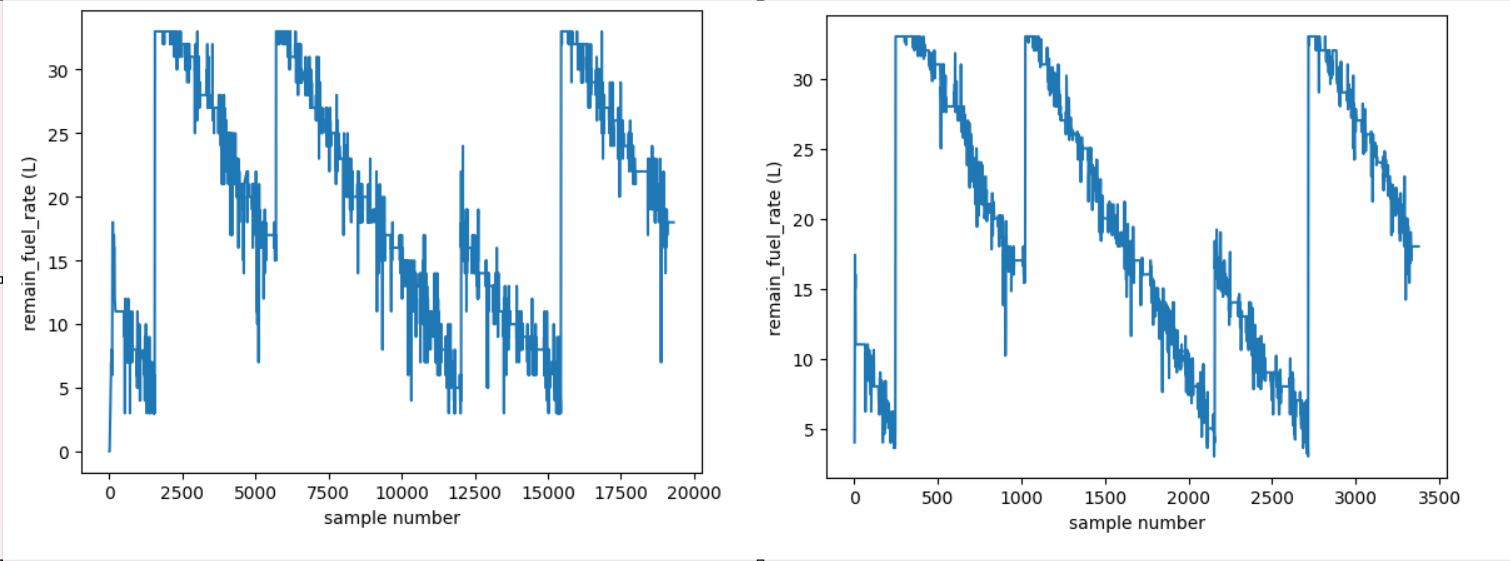

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 19302 entries, 22 to 28177
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         19302 non-null  int64  
 1   i_off        19302 non-null  int64  
 2   io           19302 non-null  str    
 3   odometer     19302 non-null  int64  
 4   date         19302 non-null  str    
 5   ext_ps       19302 non-null  float64
 6   speed        19302 non-null  int64  
 7   acc_fuel_c   19302 non-null  float64
 8   rpm          19302 non-null  str    
 9   remain_fuel  19302 non-null  str    
 10  gnss         19302 non-null  int64  
 11  cool_temp    19302 non-null  int64  
 12  Status       19302 non-null  str    
 13  engine_load  19302 non-null  int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 2.2 MB


Cooling fluid Temperature 

96 0


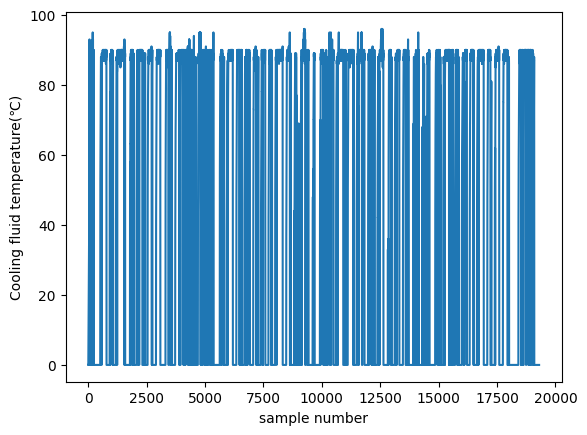

In [13]:
temp=pd.DataFrame()
temp_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
temp['sample_number']=x_axis
temp['date']=date
temp['temp']=temp_data
temp['status']=status

plt.ylabel("Cooling fluid temperature(℃)")
plt.xlabel('sample number')
plt.plot(x_axis,temp_data)

temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\temp.csv')

Engine load

96 0


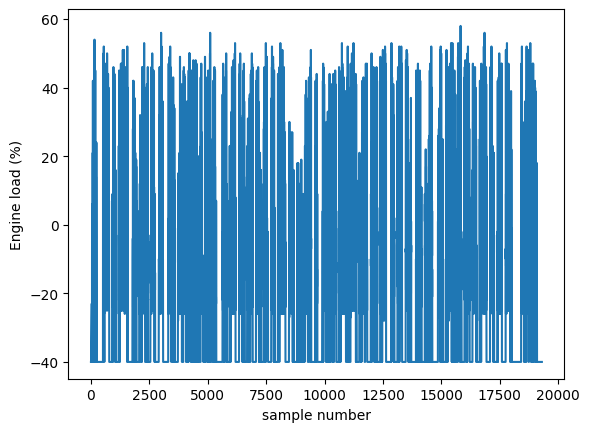

In [14]:
engine_load=pd.DataFrame()
engine_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
engine_load['sample_number']=x_axis
engine_load['date']=date
engine_load['engine load %']=engine_data
engine_load['status']=status

plt.ylabel("Engine load (%)")
plt.xlabel('sample number')
plt.plot(x_axis,engine_data)

temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\engine.csv')


In [15]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\historicallocations.xlsx')
hl.info()

<class 'pandas.DataFrame'>
RangeIndex: 2890 entries, 0 to 2889
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Secuencia       2890 non-null   int64  
 1   Unidad          2890 non-null   str    
 2   Eventos         2890 non-null   str    
 3   Fecha           2890 non-null   str    
 4   Pt. Referencia  693 non-null    str    
 5   Dirección       2890 non-null   str    
 6   Velocidad       2890 non-null   int64  
 7   Temperatura     0 non-null      float64
 8   Conductor       0 non-null      float64
 9   Latitud         2890 non-null   float64
 10  Longitud        2890 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 248.5 KB


In [16]:
hl['Eventos'].value_counts()

Eventos
Conduciendo             1051
Estacionado             1019
Inmóvil - Detenido       632
Saliendo de Landmark      63
Entrando a Landmark       62
Ignición Encendida        32
Ignición Apagada          31
Name: count, dtype: int64

Activities report

In [17]:
ars=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Activity Report_v3.csv',sep=',')
ars['MilesDriven_in_Miles']=0.0
cad_str_to_float=[]
ars.info()

<class 'pandas.DataFrame'>
RangeIndex: 394 entries, 0 to 393
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GroupName             0 non-null      float64
 1   UnitName              394 non-null    str    
 2   StartTime             394 non-null    str    
 3   MovingTimeSecs        394 non-null    str    
 4   MilesDriven           388 non-null    str    
 5   MaxSpeed              394 non-null    int64  
 6   StopTime              394 non-null    str    
 7   textbox43             394 non-null    str    
 8   StopLengthSecs        394 non-null    str    
 9   ContactName           394 non-null    str    
 10  textbox45             394 non-null    str    
 11  textbox54             394 non-null    int64  
 12  textbox28             394 non-null    str    
 13  textbox29             394 non-null    str    
 14  textbox30             394 non-null    int64  
 15  textbox32             394 non-null

MilesDriven

In [18]:
for i in range(0,ars.shape[0]):
    try:
        ars.iloc[i,4].replace(',','.')
    except:
        print("Data error on: ",ars.iloc[i,2])

Data error on:  29/05/2026 6:46 p.m.
Data error on:  29/05/2026 8:59 p.m.
Data error on:  30/05/2026 8:57 a.m.
Data error on:  30/05/2026 10:05 a.m.
Data error on:  30/05/2026 1:12 p.m.
Data error on:  31/05/2026 6:55 a.m.


In [19]:
odometer.info()

<class 'pandas.DataFrame'>
RangeIndex: 19253 entries, 0 to 19252
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   sample_number  19253 non-null  int64
 1   odometer       19253 non-null  int64
 2   date           19253 non-null  str  
 3   status         19253 non-null  str  
dtypes: int64(2), str(2)
memory usage: 601.8 KB


In [20]:
odometer_distance=odometer
odometer_cad=[]

for i in range(0,odometer.shape[0]):
    odometer_cad.append(str(odometer.iloc[i,2]))

odometer_distance['date str']=odometer_cad
odometer_distance.info()

value=input('Type the date to look for: ')
date_distance_error=odometer_distance[odometer_distance['date str'].str.contains(value)]
print(date_distance_error)

date_distance_error.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\date_distance_error.csv')

<class 'pandas.DataFrame'>
RangeIndex: 19253 entries, 0 to 19252
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   sample_number  19253 non-null  int64
 1   odometer       19253 non-null  int64
 2   date           19253 non-null  str  
 3   status         19253 non-null  str  
 4   date str       19253 non-null  str  
dtypes: int64(2), str(3)
memory usage: 752.2 KB
       sample_number  odometer          date  \
827              876  86448842  260526202632   
2848            2897  86539205  260529122026   
5024            5073  86652541  260531202621   
7203            7252  86765322  260604012026   
8619            8668  86822043  260606012026   
8963            9012  86827239  260606202623   
10118          10167  86864000  260608202612   
10119          10168  86864000  260608202637   
11024          11073  86905500  260609202608   
13356          13405  87008888  260612192026   
14861          14910  87039124  2

StopLength

In [21]:
stop_negative=ars[ars['StopLengthSecs'].str.contains('-')]
stop_negative.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GroupName             0 non-null      float64
 1   UnitName              0 non-null      str    
 2   StartTime             0 non-null      str    
 3   MovingTimeSecs        0 non-null      str    
 4   MilesDriven           0 non-null      str    
 5   MaxSpeed              0 non-null      int64  
 6   StopTime              0 non-null      str    
 7   textbox43             0 non-null      str    
 8   StopLengthSecs        0 non-null      str    
 9   ContactName           0 non-null      str    
 10  textbox45             0 non-null      str    
 11  textbox54             0 non-null      int64  
 12  textbox28             0 non-null      str    
 13  textbox29             0 non-null      str    
 14  textbox30             0 non-null      int64  
 15  textbox32             0 non-null      str    


MaxSpeed

In [22]:
for i in range(0,ars.shape[0]):
    if ars.iloc[i,5]<0:
        print(ars.iloc[i])